In [3]:
import os
while not os.path.isdir('.git'):
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

from neuron import h
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_utils import NeuronUtils
from neuron_plots import NeuronPlots

import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

import glob
import re

project = "temporal-interference"

# In-vivo inputs

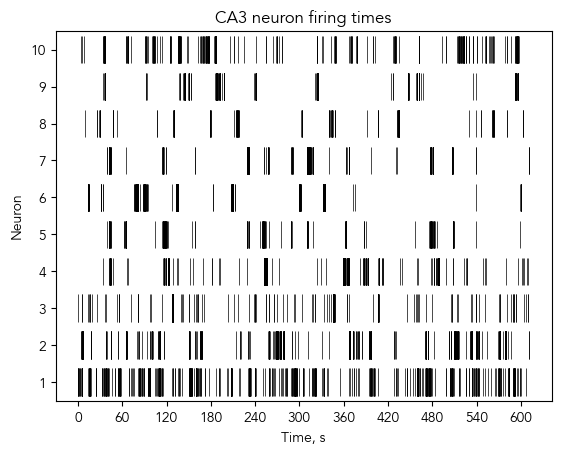

In [4]:
for i, file in enumerate(glob.glob("CA3-INVIVO-STIM/*.txt")):
    data = pd.read_csv(file, header = None)
    data.columns = ["Time"]
    data.Time = data.Time / 1000
    plt.eventplot(data.Time, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

plt.ylim(0.5, 10.5)
plt.ylabel("Neuron")
plt.yticks(np.arange(1, 11, 1))

plt.xlabel("Time, s")
plt.xticks(np.arange(0, 660, 60))

plt.title("CA3 neuron firing times")
plt.show()

**Figure.** CA3 neuron firing times, recorded *in-vivo*.

In [23]:
stimuli = []

for i, file in enumerate(glob.glob("CA3-INVIVO-STIM/*.txt")):
    data = pd.read_csv(file, header = None)
    data.columns = [f"{i}"]
    data = data.sort_values(by = f"{i}")
    
    stimuli.append(data)

In [25]:
pd.concat(stimuli, axis = 1)

,0,1,2,3,4,5,6,7,8,9
0,449.45,4729.75,303.50,34330.35,39259.80,13531.40,39371.30,9746.50,34372.55,4207.80
1,453.80,4774.50,4950.25,42468.70,41913.05,13636.30,39858.70,25603.15,35150.10,5546.25
2,565.35,4958.80,5557.15,42477.80,42133.35,13683.55,42354.85,25837.45,36233.20,7893.30
3,639.85,5157.25,13086.35,42876.10,42142.25,13724.70,42416.40,28984.45,36356.05,34365.85
4,771.30,5178.65,14946.85,42886.95,42147.00,13739.80,42426.85,29189.35,36370.95,34455.45
...,...,...,...,...,...,...,...,...,...,...
527,599766.35,579708.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
528,607006.65,582009.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
529,NaN,586164.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
530,NaN,611069.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
